In [5]:
!pip install lightkurve wotan astropy xgboost -q

In [6]:
import numpy as np
import pandas as pd
import lightkurve as lk
from wotan import flatten
from astropy.timeseries import BoxLeastSquares
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers, models

import warnings
warnings.filterwarnings("ignore")

# BLS-transit pipeline
Cells 3-7 are single target (Kepler-90) for testing the BLS transit-search pipeline: fetching one star's light curve, detrending it, running BLS/iterative BLS to find candidate transit signals in that one star. 

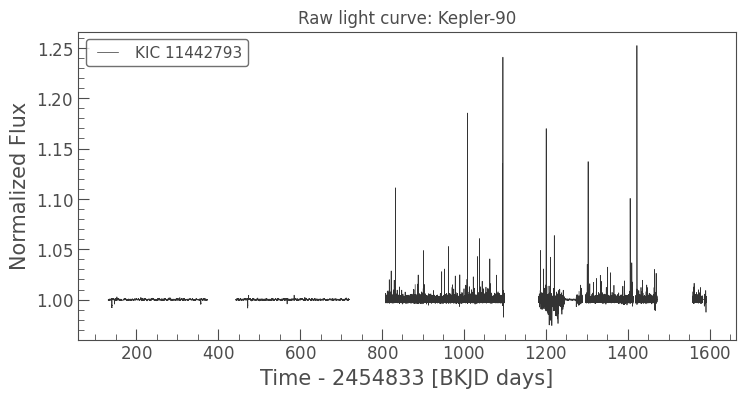

In [7]:
target_name = "Kepler-90"

search_result = lk.search_lightcurve(target_name, mission="Kepler", author="Kepler")
lc_collection = search_result.download_all()
lc = lc_collection.stitch()

lc.plot()
plt.title(f"Raw light curve: {target_name}")
plt.show()

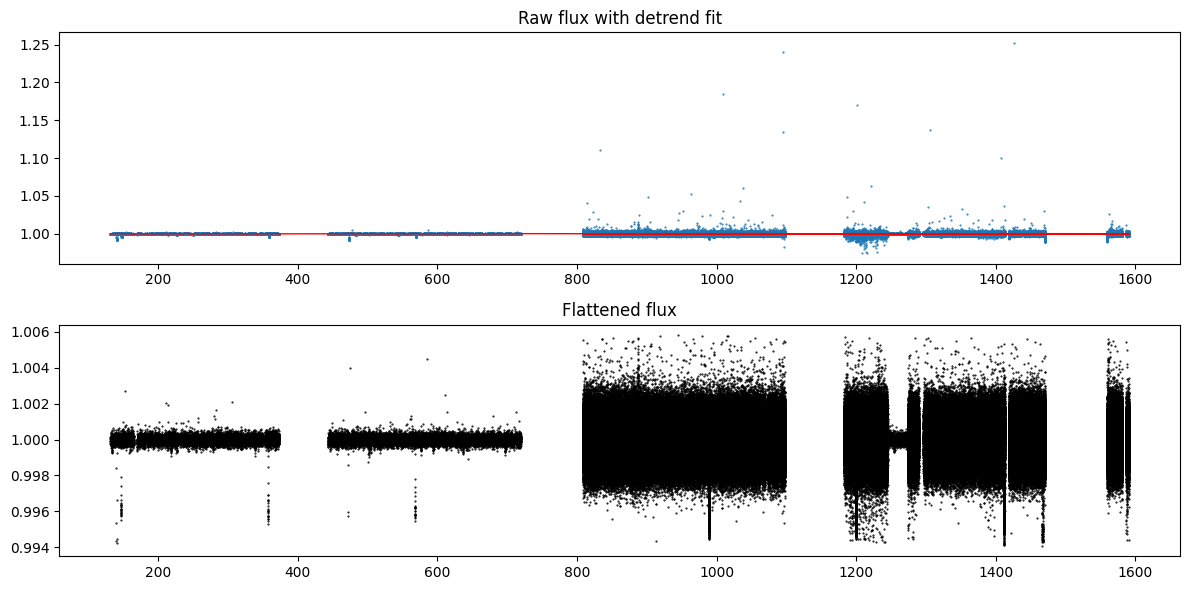

In [8]:
def preprocess_lightcurve(lc, window_length=0.5, sigma=5):
    lc_clean = lc.remove_nans()
    time = lc_clean.time.value
    flux = lc_clean.flux.value

    # sigma clip
    flux_clipped = np.copy(flux)
    med = np.nanmedian(flux_clipped)
    std = np.nanstd(flux_clipped)
    mask = np.abs(flux_clipped - med) < sigma * std
    time_clipped = time[mask]
    flux_clipped = flux_clipped[mask]

    # detrend
    flux_flat, trend = flatten(
        time_clipped, flux_clipped,
        window_length=window_length,
        method="biweight",
        return_trend=True
    )

    # wotan can leave NaNs near gaps/edges -- strip them out before BLS ever sees this
    finite_mask = np.isfinite(flux_flat)
    time_clipped = time_clipped[finite_mask]
    flux_flat = flux_flat[finite_mask]
    trend = trend[finite_mask]

    return time_clipped, flux_flat, trend


search_result = lk.search_lightcurve("Kepler-90", mission="Kepler", author="Kepler")
lc = search_result.download_all().stitch()
time_c, flux_f, trend = preprocess_lightcurve(lc, window_length=2.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(time_clean, lc.flux.value[:len(time_clean)], '.', ms=1)
axes[0].plot(time_clean, trend, 'r-', lw=1)
axes[0].set_title("Raw flux with detrend fit")

axes[1].plot(time_c, flux_f, '.', ms=1, color='black')
axes[1].set_title("Flattened flux")
plt.tight_layout()
plt.show()

In [9]:
print(lc.time.format)  # should print 'bkjd' for Kepler data
print(lc.time.scale)
print(len(time_clean))
print(time_clean.max() - time_clean.min(), "days baseline")

bkjd
tdb
847304
1459.4992184459697 days baseline


BLS search:   0%|          | 0/10 [00:00<?, ?it/s]

{'period': np.float64(140.7703851925963), 't0': np.float64(144.8349394588347), 'duration': np.float64(0.435), 'power': np.float64(0.005291432187341874), 'depth': np.float64(0.00228044398180362), 'depth_snr': np.float64(0.10274943861074658), 'is_significant': np.False_}


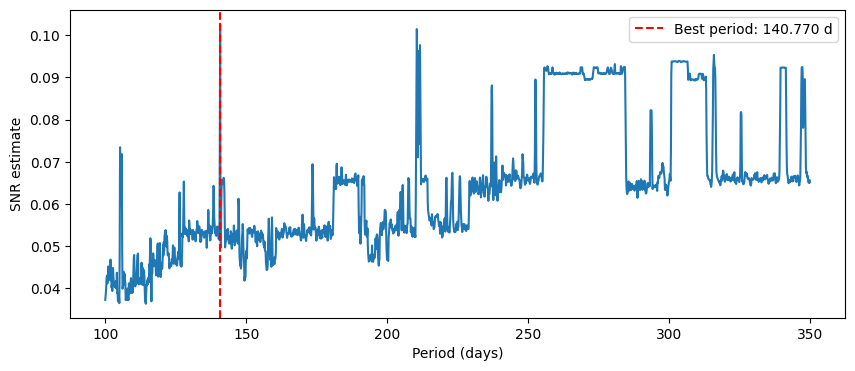

In [10]:
from tqdm.notebook import tqdm

def run_bls_manual_grid(time_arr, flux, min_period=0.5, max_period=50, duration_grid=None,
                          n_periods=5000, min_snr_threshold=6.0):
    if duration_grid is None:
        duration_grid = np.linspace(0.05, 0.5, 8)

    periods = np.linspace(min_period, max_period, n_periods)
    bls = BoxLeastSquares(time_arr, flux)
    chunk_size = 200
    all_power, all_duration, all_t0, all_depth, all_depth_snr = [], [], [], [], []

    for i in tqdm(range(0, len(periods), chunk_size), desc="BLS search"):
        chunk = periods[i:i+chunk_size]
        result = bls.power(chunk, duration_grid)
        all_power.append(result.power)
        all_duration.append(result.duration)
        all_t0.append(result.transit_time)
        all_depth.append(result.depth)
        all_depth_snr.append(result.depth_snr)

    power = np.concatenate(all_power)
    duration = np.concatenate(all_duration)
    t0 = np.concatenate(all_t0)
    depth = np.concatenate(all_depth)
    depth_snr = np.concatenate(all_depth_snr)

    best_idx = np.argmax(depth_snr)

    result = {
        "period": periods[best_idx],
        "t0": t0[best_idx],
        "duration": duration[best_idx],
        "power": power[best_idx],
        "depth": depth[best_idx],
        "depth_snr": depth_snr[best_idx],
        "is_significant": depth_snr[best_idx] >= min_snr_threshold,  # <-- new
    }

    periodogram = type("Periodogram", (), {
        "period": periods, "power": power, "duration": duration,
        "transit_time": t0, "depth": depth, "depth_snr": depth_snr
    })()

    return bls, periodogram, result

bls, periodogram, best = run_bls_manual_grid(time_clean, flux_f, min_period=100, max_period=350, n_periods=2000)
print(best)

plt.figure(figsize=(10, 4))
plt.plot(periodogram.period, periodogram.depth_snr)
plt.axvline(best["period"], color='r', linestyle='--', label=f"Best period: {best['period']:.3f} d")
plt.xlabel("Period (days)")
plt.ylabel("SNR estimate")
plt.legend()
plt.show()

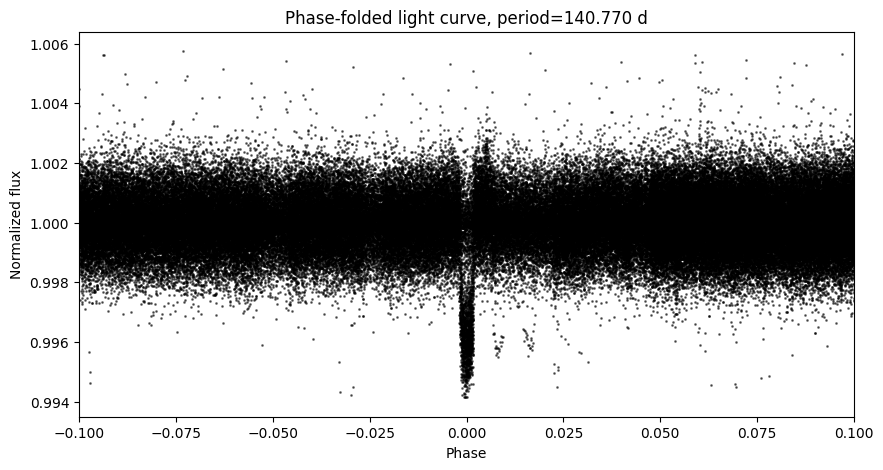

In [11]:
def phase_fold(time, flux, period, t0):
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    order = np.argsort(phase)
    return phase[order], flux[order]

phase, flux_folded = phase_fold(time_clean, flux_f, best["period"], best["t0"])

plt.figure(figsize=(10, 5))
plt.plot(phase, flux_folded, '.', ms=2, color='black', alpha=0.5)
plt.xlim(-0.1, 0.1)
plt.xlabel("Phase")
plt.ylabel("Normalized flux")
plt.title(f"Phase-folded light curve, period={best['period']:.3f} d")
plt.show()

In [12]:
def filter_harmonics(candidates_df, tolerance=0.03):
    """
    Removes candidates whose period is suspiciously close to a simple
    multiple/fraction of an earlier (stronger) candidate's period --
    a common BLS artifact, not a real independent planet.
    """
    if len(candidates_df) <= 1:
        return candidates_df

    keep_rows = [candidates_df.iloc[0]]  # always keep the strongest candidate

    for i in range(1, len(candidates_df)):
        row = candidates_df.iloc[i]
        is_harmonic = False

        for kept_row in keep_rows:
            ratio = row["period"] / kept_row["period"]
            nearest_simple_ratio = round(ratio * 2) / 2  # checks halves, wholes, etc.
            if abs(ratio - nearest_simple_ratio) < tolerance and nearest_simple_ratio in [0.5, 1.0, 1.5, 2.0, 3.0]:
                is_harmonic = True
                break

        if not is_harmonic:
            keep_rows.append(row)

    return pd.DataFrame(keep_rows).reset_index(drop=True)

In [76]:
from tqdm.notebook import tqdm
import pandas as pd

import numpy as np
from astropy.timeseries import BoxLeastSquares


def iterative_bls_search(time, flux, n_planets=3, min_period=0.5, max_period=50,
                          duration_grid=None, n_periods=3000, mask_margin=2.5,
                          min_snr_threshold=3.0):
    """
    mask_margin: multiplier applied to detected duration before masking, to
                 ensure the full transit is removed before the next search.
    min_snr_threshold: minimum SNR (computed via extract_features, i.e.
                        depth / out-of-transit noise std) required to accept
                        a candidate as real. This is NOT astropy's internal
                        depth_snr statistic -- that's on a different, unvalidated
                        scale. This uses the same SNR definition you've validated
                        against real, visually-confirmed Kepler-90 detections
                        throughout this project (real candidates ~3-5, noise ~0.1).
    """
    if duration_grid is None:
        duration_grid = np.linspace(0.05, 0.5, 8)

    candidates = []
    flux_residual = np.copy(flux)
    periods = np.linspace(min_period, max_period, n_periods)
    chunk_size = 200

    for planet_i in range(n_planets):
        bls = BoxLeastSquares(time, flux_residual)

        all_power, all_duration, all_t0, all_depth = [], [], [], []

        for i in tqdm(range(0, len(periods), chunk_size),
                      desc=f"Planet {planet_i + 1}/{n_planets} BLS search"):
            chunk = periods[i:i+chunk_size]
            result = bls.power(chunk, duration_grid)
            all_power.append(result.power)
            all_duration.append(result.duration)
            all_t0.append(result.transit_time)
            all_depth.append(result.depth)

        power = np.concatenate(all_power)
        duration = np.concatenate(all_duration)
        t0 = np.concatenate(all_t0)
        depth = np.concatenate(all_depth)

        # rank by raw BLS power to pick the candidate (as before) --
        # the real quality gate happens AFTER, using extract_features' SNR
        best_idx = np.argmax(power)
        period = periods[best_idx]
        best_t0 = t0[best_idx]
        best_duration = duration[best_idx]
        best_power = power[best_idx]
        best_depth = depth[best_idx]

        # compute the SAME SNR definition used throughout this project
        # (depth / out-of-transit noise), not astropy's internal depth_snr
        feat = extract_features(time, flux_residual, period, best_t0, best_duration)
        candidate_snr = feat["snr"]

        print(f"Planet {planet_i + 1} candidate: period={period:.3f}, "
              f"depth={best_depth:.5f}, SNR={candidate_snr:.2f}")

        if candidate_snr < min_snr_threshold:
            print(f"Stopping search after {planet_i} planet(s): "
                  f"candidate SNR ({candidate_snr:.2f}) below threshold ({min_snr_threshold})")
            break

        candidates.append({
            "planet_number": planet_i + 1,
            "period": period,
            "t0": best_t0,
            "duration": best_duration,
            "power": best_power,
            "depth": best_depth,
            "snr": candidate_snr,
        })

        widened_duration = best_duration * mask_margin
        mask = bls.transit_mask(time, period, widened_duration, best_t0)
        flux_residual[mask] = np.nanmedian(flux_residual)

    return pd.DataFrame(candidates)

result = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=100, max_period=350, n_periods=3000,
    mask_margin=2.5, min_snr_threshold=3.0
)
print(result)

result.to_csv("candidates_df_v2.csv", index=False)
result

Planet 1/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 1 candidate: period=140.764, depth=0.00232, SNR=3.20


Planet 2/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 2 candidate: period=293.481, depth=0.00316, SNR=3.65


Planet 3/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 3 candidate: period=342.664, depth=0.00476, SNR=5.42
   planet_number      period          t0  duration     power     depth  \
0              1  140.763588  144.889939     0.435  0.005454  0.002315   
1              2  293.481160  319.617439     0.500  0.003399  0.003159   
2              3  342.664221  438.922439     0.500  0.000658  0.004765   

        snr  
0  3.195342  
1  3.653893  
2  5.419617  


,planet_number,period,t0,duration,power,depth,snr
0,1,140.763588,144.889939,0.435,0.005454,0.002315,3.195342
1,2,293.481160,319.617439,0.500,0.003399,0.003159,3.653893
2,3,342.664221,438.922439,0.500,0.000658,0.004765,5.419617


In [14]:
def extract_features(time, flux, period, t0, duration):
    """
    Extract physically-motivated features from a BLS candidate for classification.
    """
    features = {}

    # basic BLS outputs
    features["period"] = period
    features["duration"] = duration

    # phase fold at this candidate's period
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    in_transit = np.abs(phase) < (duration / period) / 2

    if in_transit.sum() < 3:
        # not enough points to characterize — return NaNs, will get filtered later
        features["depth"] = np.nan
        features["snr"] = np.nan
        features["odd_even_depth_diff"] = np.nan
        features["secondary_eclipse_depth"] = np.nan
        features["num_transits_observed"] = 0
        return features

    out_of_transit_flux = flux[~in_transit]
    in_transit_flux = flux[in_transit]

    baseline = np.nanmedian(out_of_transit_flux)
    depth = baseline - np.nanmedian(in_transit_flux)
    noise = np.nanstd(out_of_transit_flux)

    features["depth"] = depth
    features["snr"] = depth / noise if noise > 0 else 0

    # odd/even transit check
    transit_number = np.floor((time - t0) / period + 0.5)
    odd_mask = in_transit & (transit_number % 2 == 1)
    even_mask = in_transit & (transit_number % 2 == 0)

    if odd_mask.sum() > 1 and even_mask.sum() > 1:
        odd_depth = baseline - np.nanmedian(flux[odd_mask])
        even_depth = baseline - np.nanmedian(flux[even_mask])
        features["odd_even_depth_diff"] = abs(odd_depth - even_depth)
    else:
        features["odd_even_depth_diff"] = np.nan

    # secondary eclipse check (phase ~0.5)
    secondary_mask = np.abs(np.abs(phase) - 0.5) < (duration / period) / 2
    if secondary_mask.sum() > 2:
        secondary_flux = np.nanmedian(flux[secondary_mask])
        features["secondary_eclipse_depth"] = baseline - secondary_flux
    else:
        features["secondary_eclipse_depth"] = np.nan

    features["num_transits_observed"] = len(np.unique(transit_number[in_transit]))

    return features

# test on the best candidate from Cell 5
print("from run_bls_manual_grid")
feat = extract_features(time_clean, flux_f, best["period"], best["t0"], best["duration"])
print(feat)
print()

print("from iterative_bls_search)")
for _, row in candidates_df.iterrows():
    feat = extract_features(time_clean, flux_f, row["period"], row["t0"], row["duration"])
    print(f"Planet {int(row['planet_number'])}: SNR={feat['snr']:.2f}, depth={feat['depth']:.5f}")

from run_bls_manual_grid
{'period': np.float64(140.7703851925963), 'duration': np.float64(0.435), 'depth': np.float64(0.0028825607111161444), 'snr': np.float64(3.11119221613108), 'odd_even_depth_diff': np.float64(0.0023560776323081623), 'secondary_eclipse_depth': np.float64(-8.588850072199783e-05), 'num_transits_observed': 7}

from iterative_bls_search)


In [ ]:
i=0
for _, row in candidates_df.iterrows():
    i=i+1
    phase, flux_folded = phase_fold(time_clean, flux_flat, row["period"], row["t0"])
    plt.figure(figsize=(10, 5))
    plt.plot(phase, flux_folded, '.', ms=2, color='black', alpha=0.5)
    plt.xlim(-0.025, 0.025)
    plt.xlabel("Phase")
    plt.ylabel("Normalized flux")
    plt.title(f"Planet {i} Phase-folded light curve, period={row['period']:.3f} d")
    plt.show()

# training XGBoost on NASA Exoplanet Archive Cumulative KOI table

In [16]:
import pandas as pd
koi_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv"
koi_df = pd.read_csv(koi_url)

print(koi_df.shape)
koi_df[["kepoi_name", "koi_disposition", "koi_period", "koi_duration", "koi_depth", "koi_model_snr"]].head()

(9564, 153)


,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_model_snr
0,K00752.01,CONFIRMED,9.488036,2.95750,615.8,35.8
1,K00752.02,CONFIRMED,54.418383,4.50700,874.8,25.8
2,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,76.3
3,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,505.6
4,K00755.01,CONFIRMED,2.525592,1.65450,603.3,40.9


In [17]:
print([c for c in koi_df.columns if "odd" in c.lower() or "even" in c.lower() or "secondary" in c.lower() or "sec_" in c.lower()])

[]


In [18]:
def prepare_koi_training_data_v2(koi_df, exclude_kepids=None):
    df = koi_df.copy()
    df = df[df["koi_disposition"].isin(["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"])]
    df["label"] = (df["koi_disposition"] != "FALSE POSITIVE").astype(int)

    if exclude_kepids is not None:
        df = df[~df["kepid"].isin(exclude_kepids)]

    feature_cols = ["koi_period", "koi_duration", "koi_depth", "koi_model_snr", "koi_num_transits"]
    df = df.dropna(subset=feature_cols + ["label"])

    X = df[feature_cols]
    y = df["label"]
    return X, y, df

# get Kepler-90's kepid to exclude before training
demo_kepids = koi_df[koi_df["kepler_name"].str.contains("Kepler-90", na=False)]["kepid"].unique().tolist()

X_v2, y_v2, koi_clean_v2 = prepare_koi_training_data_v2(koi_df, exclude_kepids=demo_kepids)

print(X_v2.shape, y_v2.value_counts())

(8295, 5) label
1    4206
0    4089
Name: count, dtype: int64


In [19]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

gbt_model_v2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

gbt_model_v2.fit(X_train_v2, y_train_v2)

y_pred_v2 = gbt_model_v2.predict(X_test_v2)
y_proba_v2 = gbt_model_v2.predict_proba(X_test_v2)[:, 1]

print(classification_report(y_test_v2, y_pred_v2))
print("ROC AUC:", roc_auc_score(y_test_v2, y_proba_v2))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       818
           1       0.81      0.87      0.84       841

    accuracy                           0.83      1659
   macro avg       0.83      0.83      0.83      1659
weighted avg       0.83      0.83      0.83      1659

ROC AUC: 0.897435524712983


In [20]:
def extract_features_v2(time, flux, period, t0, duration):
    raw = extract_features(time, flux, period, t0, duration)

    return {
        "koi_period": raw["period"],
        "koi_duration": raw["duration"] * 24,       # days -> hours
        "koi_depth": raw["depth"] * 1e6,              # flux fraction -> ppm
        "koi_model_snr": raw["snr"],
        "koi_num_transits": raw["num_transits_observed"],
        "odd_even_depth_diff": raw["odd_even_depth_diff"],
        "secondary_eclipse_depth": raw["secondary_eclipse_depth"],
    }

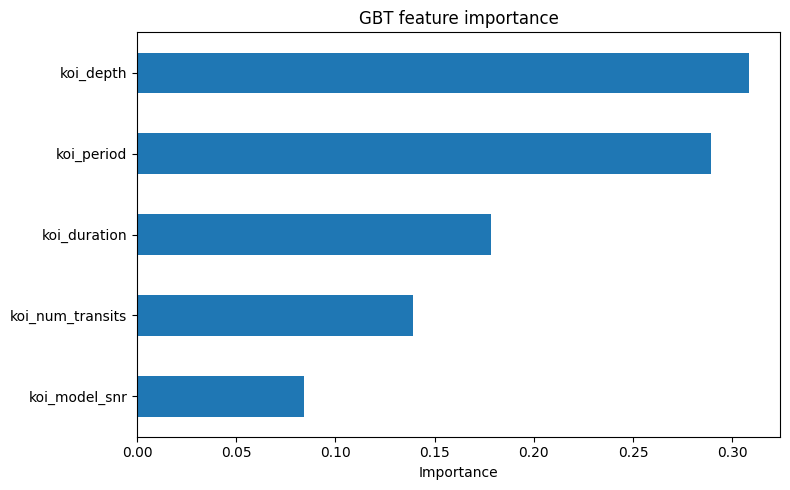

In [21]:
importances = pd.Series(gbt_model_v2.feature_importances_, index=X_v2.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.title("GBT feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [44]:
gbt_model_v2.save_model("gbt_model_v2_new.json")  # XGBoost's native format

gbt_model_v2 = xgb.XGBClassifier()
gbt_model_v2.load_model("/kaggle/input/datasets/tomatopdf/astrogng-models-dataset/astrogng/gbt_model_v2.json")

# CNN prep

In [24]:
def make_global_local_views(time, flux, period, t0, duration, global_bins=201, local_bins=61):
    """
    Bins a phase-folded light curve into fixed-length global and local views
    for CNN input, following the AstroNet-style representation.
    """
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    order = np.argsort(phase)
    phase_sorted = phase[order]
    flux_sorted = flux[order]

    # global view: bin the full phase range [-0.5, 0.5]
    global_bin_edges = np.linspace(-0.5, 0.5, global_bins + 1)
    global_view = np.full(global_bins, np.nan)
    for i in range(global_bins):
        mask = (phase_sorted >= global_bin_edges[i]) & (phase_sorted < global_bin_edges[i+1])
        if mask.sum() > 0:
            global_view[i] = np.nanmedian(flux_sorted[mask])

    # fill empty bins via interpolation
    nan_mask = np.isnan(global_view)
    if nan_mask.any() and not nan_mask.all():
        global_view[nan_mask] = np.interp(
            np.flatnonzero(nan_mask), np.flatnonzero(~nan_mask), global_view[~nan_mask]
        )

    # local view: zoom into +/- 2x transit duration around phase 0
    local_half_width = 2 * (duration / period)
    local_bin_edges = np.linspace(-local_half_width, local_half_width, local_bins + 1)
    local_view = np.full(local_bins, np.nan)
    for i in range(local_bins):
        mask = (phase_sorted >= local_bin_edges[i]) & (phase_sorted < local_bin_edges[i+1])
        if mask.sum() > 0:
            local_view[i] = np.nanmedian(flux_sorted[mask])

    nan_mask = np.isnan(local_view)
    if nan_mask.any() and not nan_mask.all():
        local_view[nan_mask] = np.interp(
            np.flatnonzero(nan_mask), np.flatnonzero(~nan_mask), local_view[~nan_mask]
        )

    return global_view, local_view

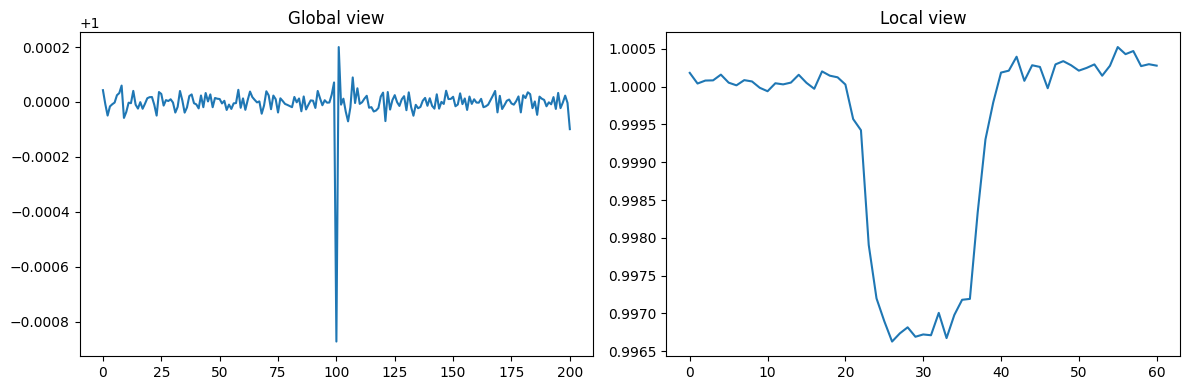

In [25]:
global_view, local_view = make_global_local_views(
    time_c, flux_f, best["period"], best["t0"], best["duration"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(global_view)
axes[0].set_title("Global view")
axes[1].plot(local_view)
axes[1].set_title("Local view")
plt.tight_layout()
plt.show()

In [26]:
def build_cnn_model(global_bins=201, local_bins=61):
    # global branch
    global_input = layers.Input(shape=(global_bins, 1), name="global_view")
    x = layers.Conv1D(16, 5, activation="relu", padding="same")(global_input)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64, 5, activation="relu", padding="same")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)

    # local branch
    local_input = layers.Input(shape=(local_bins, 1), name="local_view")
    y = layers.Conv1D(16, 5, activation="relu", padding="same")(local_input)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Conv1D(32, 5, activation="relu", padding="same")(y)
    y = layers.MaxPooling1D(2)(y)
    y = layers.Flatten()(y)

    # merge
    merged = layers.concatenate([x, y])
    z = layers.Dense(64, activation="relu")(merged)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(32, activation="relu")(z)
    output = layers.Dense(1, activation="sigmoid", name="cnn_probability")(z)

    model = models.Model(inputs=[global_input, local_input], outputs=output)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

I0000 00:00:1788684434.971114      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788684434.973904      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ global_view         │ (None, 201, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 201, 16)   │         96 │ global_view[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 16)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_view          │ (None, 61, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 32)   │      2,592 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 61, 16)    │         96 │ local_view[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 32)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 30, 16)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 50, 64)    │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 32)    │      2,592 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 25, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 15, 32)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1600)      │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 480)       │          0 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2080)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │    133,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_probability     │ (None, 1)         │         33 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,977 (589.75 KB)

 Trainable params: 150,977 (589.75 KB)

 Non-trainable params: 0 (0.00 B)

# dataset for CNN

In [29]:
import os
import re

# ---- Step 1: find which star folders actually exist locally ----
base_dir = "/kaggle/input/datasets/tomatopdf/koi-lightcurves/koi_lightcurves_ananya/mastDownload/Kepler"  # adjust path once uploaded to Kaggle
star_folders = os.listdir(base_dir)
print(f"Number of star folders found locally: {len(star_folders)}")

# ---- Step 2: extract kepid from each folder name ----
def extract_kepid_from_folder(folder_name):
    match = re.search(r"kplr(\d+)_lc", folder_name)
    if match:
        return int(match.group(1))
    return None

downloaded_kepids = [extract_kepid_from_folder(f) for f in star_folders]
downloaded_kepids = [k for k in downloaded_kepids if k is not None]
print(f"Successfully extracted {len(downloaded_kepids)} kepids from folder names")

# ---- Step 3: filter koi_clean_v2 down to only the stars you actually have locally ----
downloaded_df = koi_clean_v2[koi_clean_v2["kepid"].isin(downloaded_kepids)].copy()
print(f"Matched {downloaded_df.shape[0]} rows in koi_clean_v2 against locally available FITS files")
print(downloaded_df["label"].value_counts())

downloaded_df.head()

Number of star folders found locally: 1412
Successfully extracted 1197 kepids from folder names
Matched 1582 rows in koi_clean_v2 against locally available FITS files
label
1    975
0    607
Name: count, dtype: int64


,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score,label
9,10910878,K00757.01,Kepler-229 c,286.99948,0.0,19h07m59.88s,48.375790,0.0,+48d22m32.8s,16.559,...,0,30.75,4.46,-6.66,3.66590,0.11507,-0.51226,LS+MCMC,1.000,1
17,10485250,K00745.01,NaN,297.15442,0.0,19h48m37.06s,47.668701,0.0,+47d40m07.3s,16.529,...,0,29.61,12.01,-8.91,0.19353,0.02009,-0.01907,LS+MCMC,0.000,0
21,10601284,K00749.01,Kepler-226 c,292.37613,0.0,19h29m30.27s,47.880989,0.0,+47d52m51.6s,15.988,...,0,168.99,34.66,-38.48,1.73782,0.00625,-0.73875,LS+MCMC,1.000,1
22,10601284,K00749.02,Kepler-226 b,292.37613,0.0,19h29m30.27s,47.880989,0.0,+47d52m51.6s,15.988,...,0,253.15,51.91,-57.65,1.85636,0.37935,-0.52982,LS+MCMC,0.980,1
23,10601284,K00749.03,Kepler-226 d,292.37613,0.0,19h29m30.27s,47.880989,0.0,+47d52m51.6s,15.988,...,0,97.03,19.90,-22.09,1.53020,0.23293,-0.63643,LS+MCMC,0.971,1


In [32]:
import lightkurve as lk

def load_local_lightcurve(kepid, base_dir="/kaggle/input/datasets/tomatopdf/koi-lightcurves/koi_lightcurves_ananya/mastDownload/Kepler"):
    matching_folders = [f for f in os.listdir(base_dir) if f"kplr{kepid:09d}" in f]
    if not matching_folders:
        return None

    folder_path = os.path.join(base_dir, matching_folders[0])
    fits_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith(".fits")]

    if not fits_files:
        return None

    lc_collection = lk.LightCurveCollection([lk.read(f) for f in fits_files])
    lc = lc_collection.stitch()
    return lc

# test on one star
test_kepid = downloaded_kepids[0]
lc = load_local_lightcurve(test_kepid)
print(lc)

       time             flux      ...   pos_corr1      pos_corr2   
                                  ...      pix            pix      
------------------ -------------- ... -------------- --------------
352.37633767885563            ——— ...  4.3802164e-02 -2.1158691e-01
352.39677052588377  9.9992305e-01 ...  4.3665919e-02 -2.1148297e-01
352.43763622074766  9.9973077e-01 ...  4.3543361e-02 -2.1145278e-01
 352.4580690687071  1.0000043e+00 ...  4.3468576e-02 -2.1134026e-01
 352.4785019167757  1.0000337e+00 ...  4.3389808e-02 -2.1111970e-01
352.49893476531724  9.9988914e-01 ...  4.3428719e-02 -2.1113041e-01
 352.5193676139752  9.9993306e-01 ...  4.3421790e-02 -2.1092889e-01
352.53980036297435  1.0001873e+00 ...  4.3425623e-02 -2.1058874e-01
352.56023331233155  9.9990791e-01 ...  4.3577548e-02 -2.1071862e-01
               ...            ... ...            ...            ...
164.80025136383483  9.9983394e-01 ...  3.2009687e-02 -6.8319716e-02
164.82068569329567  9.9983203e-01 ...  3.2149050

def process_local_target_debug(args):
    idx, kepid, koi_period, koi_time0bk, koi_duration, label, base_dir, global_bins, local_bins = args
    lc = load_local_lightcurve(kepid, base_dir=base_dir)
    if lc is None:
        return None
    time_c, flux_f, _ = preprocess_lightcurve(lc, window_length=2.0)
    period = koi_period
    t0 = koi_time0bk
    duration = koi_duration / 24.0
    g_view, l_view = make_global_local_views(time_c, flux_f, period, t0, duration, global_bins=global_bins, local_bins=local_bins)
    if np.isnan(g_view).any() or np.isnan(l_view).any():
        return None
    return (idx, g_view, l_view, label)

# run through the actual pool, but with no exception swallowing
from concurrent.futures import ProcessPoolExecutor

with ProcessPoolExecutor(max_workers=2) as executor:
    future = executor.submit(process_local_target_debug, args)
    try:
        result = future.result()
        print("SUCCESS:", result[0] if result else None)
    except Exception as e:
        print(f"REAL ERROR: {type(e).__name__}: {e}")

In [ ]:
import os
print(os.cpu_count())

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm
import numpy as np

def process_local_target(args):
    idx, kepid, koi_period, koi_time0bk, koi_duration, label, base_dir, global_bins, local_bins = args
    try:
        lc = load_local_lightcurve(kepid, base_dir=base_dir)
        if lc is None:
            return None

        time_c, flux_f, _ = preprocess_lightcurve(lc, window_length=2.0)
        period = koi_period
        t0 = koi_time0bk
        duration = koi_duration / 24.0

        g_view, l_view = make_global_local_views(
            time_c, flux_f, period, t0, duration,
            global_bins=global_bins, local_bins=local_bins
        )

        if np.isnan(g_view).any() or np.isnan(l_view).any():
            return None

        return (idx, g_view, l_view, label)  # <-- carry the original index through

    except Exception:
        return None


def build_cnn_dataset_local_parallel(downloaded_df, base_dir="/kaggle/input/datasets/tomatopdf/koi-lightcurves/koi_lightcurves_ananya/mastDownload/Kepler",
                                       global_bins=201, local_bins=61, n_workers=8):
    args_list = [
        (idx, row["kepid"], row["koi_period"], row["koi_time0bk"], row["koi_duration"], row["label"],
         base_dir, global_bins, local_bins)
        for idx, row in downloaded_df.iterrows()
    ]

    successful_indices = []
    global_views, local_views, labels = [], [], []

    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = [executor.submit(process_local_target, args) for args in args_list]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing local light curves (parallel)"):
            result = future.result()
            if result is not None:
                idx, g_view, l_view, label = result
                successful_indices.append(idx)
                global_views.append(g_view)
                local_views.append(l_view)
                labels.append(label)

    print(f"Succeeded: {len(labels)} / {len(args_list)}")

    X_global = np.array(global_views)[..., np.newaxis]
    X_local = np.array(local_views)[..., np.newaxis]
    y = np.array(labels)

    # this is now correctly aligned to X_global/X_local/y, regardless of completion order
    aligned_df = downloaded_df.loc[successful_indices].reset_index(drop=True)

    return X_global, X_local, y, aligned_df

In [35]:
import os
import numpy as np
import pandas as pd

# Adjust this to match your actual published dataset's Kaggle input path once you know the real slug
PROCESSED_DATA_PATH = "/kaggle/input/datasets/tomatopdf/astrogngdata-train"

if os.path.exists(PROCESSED_DATA_PATH):
    print("Loading precomputed CNN dataset from Kaggle input...")
    X_global_mast = np.load(f"{PROCESSED_DATA_PATH}/X_global_mast.npy")
    X_local_mast = np.load(f"{PROCESSED_DATA_PATH}/X_local_mast.npy")
    y_mast = np.load(f"{PROCESSED_DATA_PATH}/y_mast.npy")
    aligned_df_mast = pd.read_csv(f"{PROCESSED_DATA_PATH}/aligned_df_mast.csv")
else:
    print("No precomputed dataset found — building from raw FITS files...")
    X_global_mast, X_local_mast, y_mast, aligned_df_mast = build_cnn_dataset_local_parallel(downloaded_df, n_workers=4)

    np.save("X_global_mast.npy", X_global_mast)
    np.save("X_local_mast.npy", X_local_mast)
    np.save("y_mast.npy", y_mast)
    aligned_df_mast.to_csv("aligned_df_mast.csv", index=False)

gbt_features_mast = aligned_df_mast[["koi_period", "koi_duration", "koi_depth", "koi_model_snr", "koi_num_transits"]]

print(X_global_mast.shape, X_local_mast.shape, y_mast.shape, gbt_features_mast.shape)

Loading precomputed CNN dataset from Kaggle input...
(1570, 201, 1) (1570, 61, 1) (1570,) (1570, 5)


In [36]:
print(pd.Series(y_mast).value_counts())

1    970
0    600
Name: count, dtype: int64


# training CNN

In [50]:
from sklearn.model_selection import train_test_split


# first split off a true test set, untouched by CNN training or early stopping
Xg_trainval, Xg_final_test, Xl_trainval, Xl_final_test, gbt_feat_trainval, gbt_feat_final_test, y_trainval, y_final_test = train_test_split(
    X_global_mast, X_local_mast, gbt_features_mast, y_mast,
    test_size=0.15, random_state=42, stratify=y_mast
)

# now split trainval into train/val for CNN's own early stopping
Xg_train, Xg_val, Xl_train, Xl_val, y_train, y_val = train_test_split(
    Xg_trainval, Xl_trainval, y_trainval,
    test_size=0.15, random_state=42, stratify=y_trainval
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor="val_auc", mode="max", patience=15, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    filepath="cnn_best_weights_new.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

cnn_model = build_cnn_model()

history = cnn_model.fit(
    [Xg_train, Xl_train], y_train,
    validation_data=([Xg_val, Xl_val], y_val),
    epochs=50,
    batch_size=16,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

cnn_model.save("cnn_transit_model_new.keras")

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5560 - auc: 0.5011 - loss: 0.6865
Epoch 1: val_auc improved from None to 0.50649, saving model to cnn_best_weights_new.keras

Epoch 1: finished saving model to cnn_best_weights_new.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.5922 - auc: 0.5074 - loss: 0.6764 - val_accuracy: 0.6169 - val_auc: 0.5065 - val_loss: 0.6683
Epoch 2/50
64/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6161 - auc: 0.4863 - loss: 0.6721
Epoch 2: val_auc improved from 0.50649 to 0.59180, saving model to cnn_best_weights_new.keras

Epoch 2: finished saving model to cnn_best_weights_new.keras
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6178 - auc: 0.4873 - loss: 0.6707 - val_accuracy: 0.6169 - val_auc: 0.5918 - val_loss: 0.6654
Epoch 3/50
64/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6136 - auc: 0.4872 - loss: 0.6708
Epoch 3: val_auc did not improve from 0.59180
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6

from tensorflow.keras.models import load_model
cnn_model = load_model("/kaggle/input/datasets/tomatopdf/astrogng-models-dataset/astrogng/cnn_transit_model_final.keras")

from tensorflow.keras.models import load_model

cnn_model = load_model("/kaggle/input/datasets/tomatopdf/astrogng-models-dataset/astrogng/cnn_best_weights.keras")

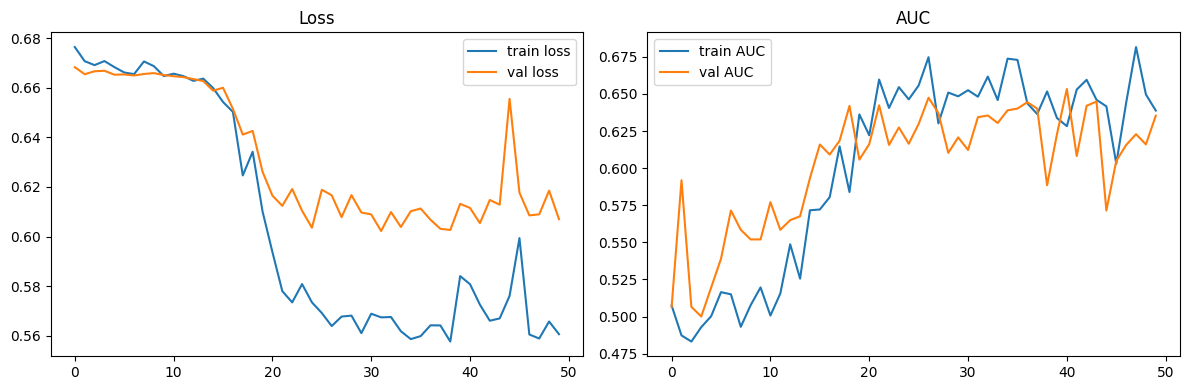

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
CNN ROC AUC: 0.5952435312024353


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train AUC")
axes[1].plot(history.history["val_auc"], label="val AUC")
axes[1].set_title("AUC")
axes[1].legend()
plt.tight_layout()
plt.show()

cnn_test_proba = cnn_model.predict([Xg_final_test, Xl_final_test]).flatten()
print("CNN ROC AUC:", roc_auc_score(y_final_test, cnn_test_proba))

# meta-classifier

In [52]:
def build_meta_training_data(gbt_model, cnn_model, gbt_features_df, X_global, X_local, y_true):
    """
    gbt_features_df: DataFrame with columns matching gbt_model's expected features
                      (koi_period, koi_duration, koi_depth, koi_model_snr, koi_num_transits)
    X_global, X_local: CNN input arrays, same row order as gbt_features_df and y_true
    y_true: true labels, same row order
    """
    gbt_proba = gbt_model.predict_proba(gbt_features_df)[:, 1]
    cnn_proba = cnn_model.predict([X_global, X_local], verbose=0).flatten()

    meta_X = pd.DataFrame({
        "gbt_proba": gbt_proba,
        "cnn_proba": cnn_proba,
    })
    meta_y = y_true

    return meta_X, meta_y

In [56]:
# meta-classifier trains on trainval predictions (still not the final test set)
from sklearn.linear_model import LogisticRegression
import joblib

meta_X_trainval, meta_y_trainval = build_meta_training_data(
    gbt_model_v2, cnn_model, gbt_feat_trainval, Xg_trainval, Xl_trainval, y_trainval
)
meta_model = LogisticRegression(class_weight="balanced")
meta_model.fit(meta_X_trainval, meta_y_trainval)

# ONLY NOW touch the final test set, once, for a real number
meta_X_test, meta_y_test = build_meta_training_data(
    gbt_model_v2, cnn_model, gbt_feat_final_test, Xg_final_test, Xl_final_test, y_final_test
)
final_test_proba = meta_model.predict_proba(meta_X_test)[:, 1]
print("Held-out ROC AUC:", roc_auc_score(meta_y_test, final_test_proba))


joblib.dump(meta_model, "meta_model_new.joblib")

Held-out ROC AUC: 0.9573820395738204


['meta_model_new.joblib']

import joblib
meta_model = joblib.load("/kaggle/input/datasets/tomatopdf/astrogng-models-dataset/astrogng/meta_model.joblib")

# integration

In [54]:
def get_final_confidence(gbt_proba, cnn_proba, meta_model):
    meta_input = pd.DataFrame({"gbt_proba": [gbt_proba], "cnn_proba": [cnn_proba]})
    return meta_model.predict_proba(meta_input)[0, 1]

In [59]:
target = "Kepler-90"
search_result = lk.search_lightcurve(target, mission="Kepler", author="Kepler")
lc_collection = search_result.download_all()
lc = lc_collection.stitch()
time_c, flux_f, _ = preprocess_lightcurve(lc, window_length=2.0)

print(f"Baseline: {time_c.max() - time_c.min():.1f} days")
print(f"Number of points: {len(time_c)}")

Baseline: 1459.5 days
Number of points: 847304


In [77]:
from tqdm.notebook import tqdm

def analyze_target(target, n_planets=3, gbt_model=None, cnn_model=None, meta_model=None,
                    window_length=2.0, min_period=5, max_period=350, n_periods=3000):
    if isinstance(target, int):
        search_target = f"KIC {target}"
    elif isinstance(target, str) and target.strip().isdigit():
        search_target = f"KIC {target.strip()}"
    else:
        search_target = target

    search_result = lk.search_lightcurve(search_target, mission="Kepler", author="Kepler")
    print(f"DEBUG: search_result found {len(search_result)} products for '{search_target}'")

    if len(search_result) == 0:
        raise ValueError(f"No Kepler data found for {target}")

    lc_collection = search_result.download_all()
    if lc_collection is None or len(lc_collection) == 0:
        raise ValueError(f"No Kepler data found for {target}")

    print(f"DEBUG: lc_collection has {len(lc_collection)} light curve files")

    lc = lc_collection.stitch()
    print(f"DEBUG: stitched lc has {len(lc.time.value)} raw points, "
          f"baseline {lc.time.value.max() - lc.time.value.min():.1f} days")

    time_c, flux_f, _ = preprocess_lightcurve(lc, window_length=window_length)
    print(f"DEBUG: after preprocessing: {len(time_c)} points, "
          f"baseline {time_c.max() - time_c.min():.1f} days, "
          f"NaN count in flux_f: {np.isnan(flux_f).sum()}")

    candidates_df = iterative_bls_search(
        time_c, flux_f, n_planets=n_planets,
        min_period=min_period, max_period=max_period, n_periods=n_periods,
        mask_margin=2.5, min_snr_threshold=6.0
    )
    candidates_df = filter_harmonics(candidates_df)

    results = []
    for _, row in tqdm(candidates_df.iterrows(), total=len(candidates_df), desc=f"Scoring candidates for {target}"):
        feat = extract_features_v2(time_c, flux_f, row["period"], row["t0"], row["duration"])
        gbt_input = pd.DataFrame([{
            "koi_period": feat["koi_period"],
            "koi_duration": feat["koi_duration"],
            "koi_depth": feat["koi_depth"],
            "koi_model_snr": feat["koi_model_snr"],
            "koi_num_transits": feat["koi_num_transits"],
        }])
        gbt_proba = gbt_model.predict_proba(gbt_input)[0, 1]
        g_view, l_view = make_global_local_views(time_c, flux_f, row["period"], row["t0"], row["duration"])
        cnn_proba = cnn_model.predict(
            [g_view[np.newaxis, ..., np.newaxis], l_view[np.newaxis, ..., np.newaxis]],
            verbose=0
        )[0, 0]
        final_confidence = get_final_confidence(gbt_proba, cnn_proba, meta_model)
        results.append({
            **row.to_dict(),
            "odd_even_depth_diff": feat["odd_even_depth_diff"],
            "secondary_eclipse_depth": feat["secondary_eclipse_depth"],
            "gbt_proba": gbt_proba,
            "cnn_proba": cnn_proba,
            "confidence": final_confidence,
        })

    return pd.DataFrame(results)

# by name
final_results = analyze_target("Kepler-90", gbt_model=gbt_model_v2, cnn_model=cnn_model, meta_model=meta_model)
print(final_results)
# by KIC number, as int
final_results = analyze_target(8838950, gbt_model=gbt_model_v2, cnn_model=cnn_model, meta_model=meta_model)
print(final_results)
# by KIC number, as string
final_results = analyze_target("8838950", gbt_model=gbt_model_v2, cnn_model=cnn_model, meta_model=meta_model)
print(final_results)

DEBUG: search_result found 33 products for 'Kepler-90'
DEBUG: lc_collection has 33 light curve files
DEBUG: stitched lc has 853536 raw points, baseline 1459.5 days


KeyboardInterrupt: 

In [62]:
candidates_df = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=100, max_period=350, n_periods=3000,  # your ORIGINAL validated range
    mask_margin=2.5, min_snr_threshold=6.0
)
print(candidates_df)

Planet 1/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Stopping search after 0 planet(s): candidate SNR (0.10) below threshold (6.0)
Empty DataFrame
Columns: []
Index: []


In [78]:
# Reproduce analyze_target's data fetch manually
search_result = lk.search_lightcurve("Kepler-90", mission="Kepler", author="Kepler")
lc = search_result.download_all().stitch()
time_c, flux_f, _ = preprocess_lightcurve(lc, window_length=2.0)

print(f"time_c: {len(time_c)} points, baseline {time_c.max()-time_c.min():.1f} days")

results_two = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=100, max_period=350, n_periods=3000,
    mask_margin=2.5, min_snr_threshold=3.0
)
print(results_two)

time_c: 847304 points, baseline 1459.5 days


Planet 1/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 1 candidate: period=140.764, depth=0.00232, SNR=3.20


Planet 2/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 2 candidate: period=293.481, depth=0.00316, SNR=3.65


Planet 3/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 3 candidate: period=342.664, depth=0.00476, SNR=5.42
   planet_number      period          t0  duration     power     depth  \
0              1  140.763588  144.889939     0.435  0.005454  0.002315   
1              2  293.481160  319.617439     0.500  0.003399  0.003159   
2              3  342.664221  438.922439     0.500  0.000658  0.004765   

        snr  
0  3.195342  
1  3.653893  
2  5.419617  


# debugging

In [70]:
# TEST 1: Does the ORIGINAL validated range still work with iterative_bls_search?
print("=== TEST 1: min_period=100, max_period=350 (your originally validated range) ===")
result1 = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=100, max_period=350, n_periods=3000,
    mask_margin=2.5, min_snr_threshold=0  # threshold=0 so it never stops early, just shows real SNR
)
print(result1)

=== TEST 1: min_period=100, max_period=350 (your originally validated range) ===


Planet 1/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 2/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 3/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

   planet_number      period          t0  duration     power     depth  \
0              1  140.763588  144.889939     0.435  0.005454  0.002315   
1              2  293.481160  319.617439     0.500  0.003399  0.003159   
2              3  342.664221  438.922439     0.500  0.000658  0.004765   

   depth_snr  
0   0.104318  
1   0.082412  
2   0.036285  


In [71]:
# TEST 2: Does run_bls_manual_grid (single-shot, no masking loop) still work on the SAME data?
print("=== TEST 2: run_bls_manual_grid, same range ===")
bls, periodogram, best = run_bls_manual_grid(
    time_c, flux_f, min_period=100, max_period=350, n_periods=2000 
)
print(best)

=== TEST 2: run_bls_manual_grid, same range ===


BLS search:   0%|          | 0/10 [00:00<?, ?it/s]

{'period': np.float64(140.7703851925963), 't0': np.float64(144.8349394588347), 'duration': np.float64(0.435), 'power': np.float64(0.005291432187341874), 'depth': np.float64(0.00228044398180362), 'depth_snr': np.float64(0.10274943861074658), 'is_significant': np.False_}


In [72]:
# TEST 3: Does widening to min_period=5 break TEST 1's result?
print("=== TEST 3: min_period=5, max_period=350 (the range analyze_target actually uses) ===")
result3 = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=5, max_period=350, n_periods=3000,
    mask_margin=2.5, min_snr_threshold=0
)
print(result3)

=== TEST 3: min_period=5, max_period=350 (the range analyze_target actually uses) ===


Planet 1/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 2/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

Planet 3/3 BLS search:   0%|          | 0/15 [00:00<?, ?it/s]

   planet_number      period          t0  duration     power     depth  \
0              1  140.745248  145.019939     0.435  0.005546  0.002332   
1              2  325.496832  223.564939     0.435  0.003405  0.003383   
2              3  331.593865  140.537439     0.500  0.000669  0.004803   

   depth_snr  
0   0.105189  
1   0.082489  
2   0.036577  


In [73]:
# TEST 4: Same wide range, but n_periods scaled up proportionally (finer resolution)
print("=== TEST 4: min_period=5, max_period=350, n_periods=10000 ===")
result4 = iterative_bls_search(
    time_c, flux_f, n_planets=3,
    min_period=5, max_period=350, n_periods=10000,
    mask_margin=2.5, min_snr_threshold=0
)
print(result4)

=== TEST 4: min_period=5, max_period=350, n_periods=10000 ===


Planet 1/3 BLS search:   0%|          | 0/50 [00:00<?, ?it/s]

Planet 2/3 BLS search:   0%|          | 0/50 [00:00<?, ?it/s]

Planet 3/3 BLS search:   0%|          | 0/50 [00:00<?, ?it/s]

   planet_number      period          t0  duration     power     depth  \
0              1  211.123612  144.984939     0.435  0.005421  0.002335   
1              2  325.399040  223.739939     0.245  0.001668  0.003302   
2              3  331.609661  140.482439     0.500  0.000686  0.004492   

   depth_snr  
0   0.104002  
1   0.057743  
2   0.037036  
